In [ ]:
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt


BASE_DIR = Path(os.getcwd()).parent
PROCESSED_DIR = BASE_DIR / "01_data" / "02_processed"
df = pd.read_csv(PROCESSED_DIR / "sensor_daily_features.csv")

df.info()
df.describe()[['critical_value','peak','spread','peak_ratio','total_count']]


<class 'pandas.DataFrame'>
RangeIndex: 15833 entries, 0 to 15832
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            15833 non-null  int64  
 1   site_name       15833 non-null  str    
 2   sensor_id       15833 non-null  int64  
 3   critical_value  15833 non-null  float64
 4   peak            15833 non-null  float64
 5   count_peak      15833 non-null  float64
 6   peak_ratio      15833 non-null  float64
 7   spread          15833 non-null  float64
 8   total_count     15833 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.1 MB


,critical_value,peak,spread,peak_ratio,total_count
count,15833.000000,15833.000000,15833.000000,15833.000000,15833.0
mean,12.298490,19.904187,29.941451,18.034473,720.0
std,13.903241,15.572800,11.195422,14.376880,0.0
min,0.000000,0.000000,0.000000,3.470000,720.0
25%,0.000000,7.000000,23.000000,10.690000,720.0
50%,7.000000,16.000000,29.000000,13.190000,720.0
75%,21.000000,30.000000,37.000000,19.170000,720.0
max,73.000000,85.000000,85.000000,100.000000,720.0


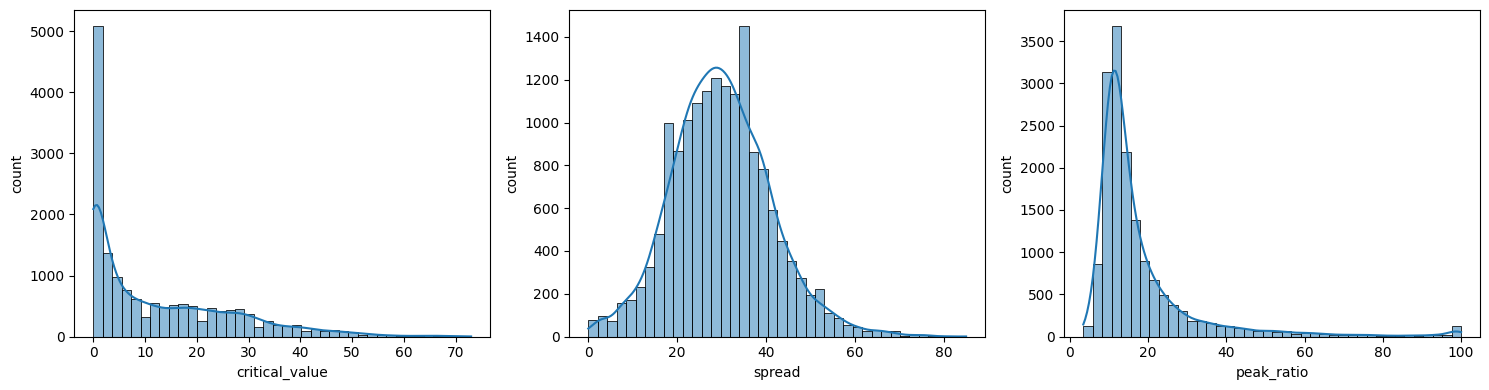

In [ ]:

## 1.critical_value, spread, peak_ratio 분포 파악


plt.figure(figsize=(15, 4))

cols = ['critical_value', 'spread', 'peak_ratio']

for i, col in enumerate(cols, start=1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=40, kde=True)
    plt.xlabel(col)
    plt.ylabel('count')

plt.tight_layout()
plt.show()



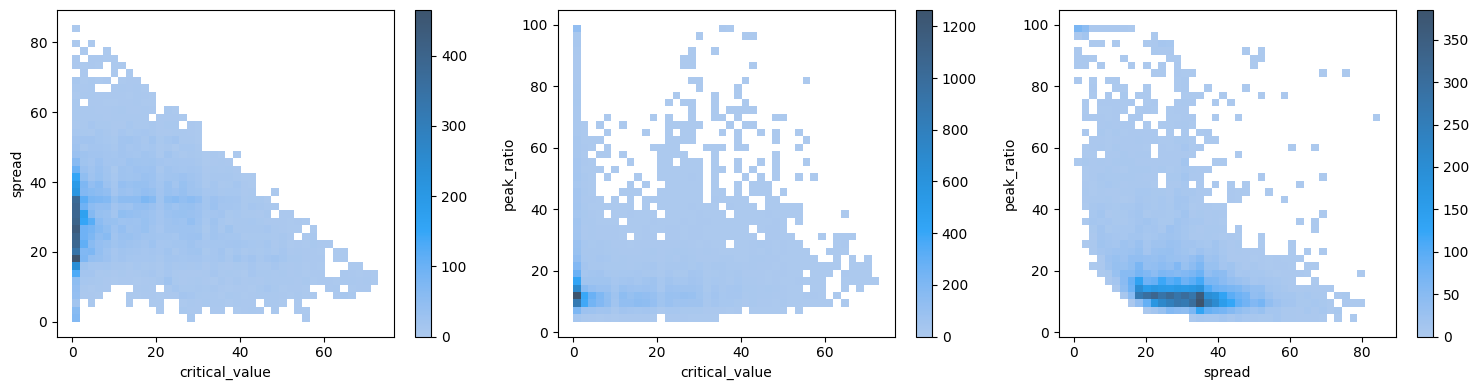

In [ ]:

## 2.feature 간 관계 보기(critical / spread / peak_ratio)
# 2-1 2D 분포(히트맵)

plt.figure(figsize=(15, 4))

# 1) critical_value vs spread
plt.subplot(1, 3, 1)
sns.histplot(
    data=df,
    x='critical_value',
    y='spread',
    bins=40,
    cbar=True
)
plt.xlabel('critical_value')
plt.ylabel('spread')

# 2) critical_value vs peak_ratio
plt.subplot(1, 3, 2)
sns.histplot(
    data=df,
    x='critical_value',
    y='peak_ratio',
    bins=40,
    cbar=True
)
plt.xlabel('critical_value')
plt.ylabel('peak_ratio')

# 3) spread vs peak_ratio
plt.subplot(1, 3, 3)
sns.histplot(
    data=df,
    x='spread',
    y='peak_ratio',
    bins=40,
    cbar=True
)
plt.xlabel('spread')
plt.ylabel('peak_ratio')

plt.tight_layout()
plt.show()


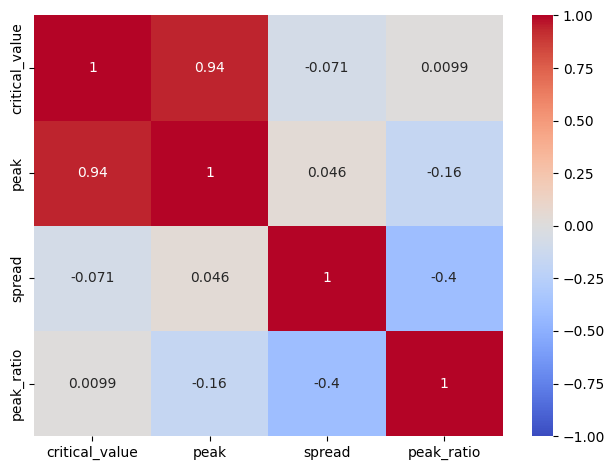

In [6]:
# 2-2 상관계수 매트릭스

cols = ['critical_value','peak','spread','peak_ratio']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()



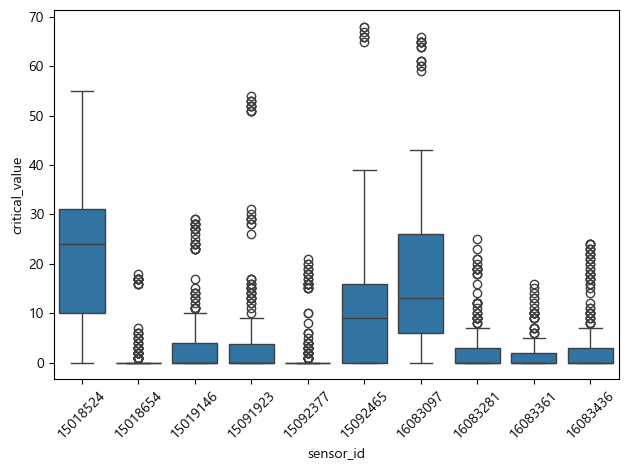

In [9]:
## 3.센서 / 현장 별 분석
## 3-1 센서별 boxplot

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

top_sensors = df['sensor_id'].value_counts().head(10).index

sns.boxplot(
    data=df[df['sensor_id'].isin(top_sensors)],
    x='sensor_id', y='critical_value'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


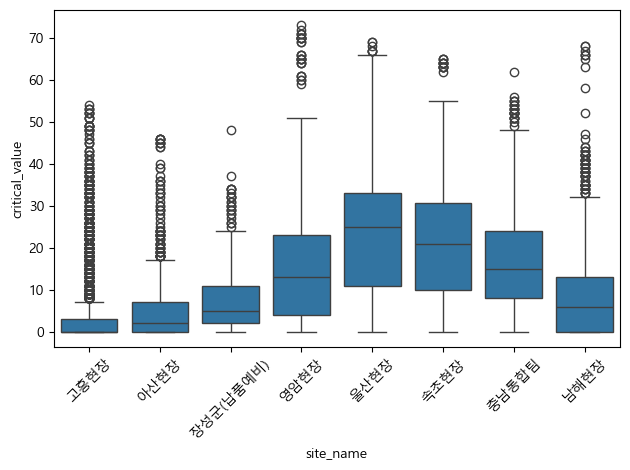

In [10]:
## 3-2 현장별 boxplot

top_sites = df['site_name'].value_counts().head(8).index
sns.boxplot(
    data=df[df['site_name'].isin(top_sites)],
    x='site_name', y='critical_value'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



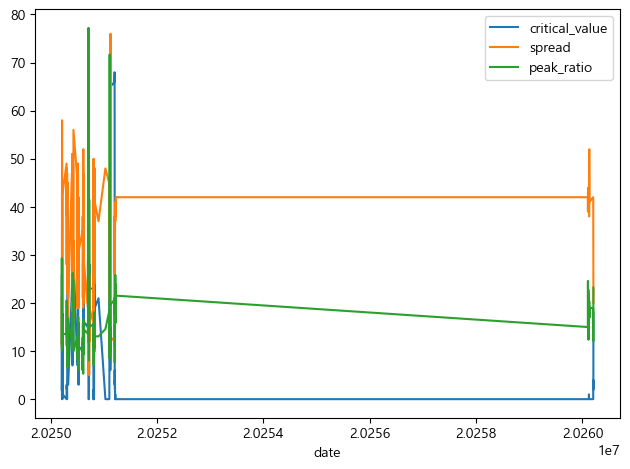

In [12]:
## 4. 시간축 패턴 
# 4-1. 특정 센서 1개 골라서 타임 시리즈
sid = df['sensor_id'].value_counts().idxmax()  # 데이터 가장 많은 센서
temp = df[df['sensor_id'] == sid].sort_values('date')

temp.plot(x='date', y=['critical_value','spread','peak_ratio'])
plt.tight_layout()
plt.show()


In [15]:
## 5. 극단치 확인
## 5-1 0.95 이상만 필터링
c_p95 = df['critical_value'].quantile(0.95)
s_p95 = df['spread'].quantile(0.95)
pr_p95 = df['peak_ratio'].quantile(0.95)

outliers = df[
    (df['critical_value'] >= c_p95) |
    (df['spread'] >= s_p95) |
    (df['peak_ratio'] >= pr_p95)
]

outliers.head()


,date,site_name,sensor_id,critical_value,peak,count_peak,peak_ratio,spread,total_count
14,20241017,원주현장,15018524,7.0,16.0,98.0,13.61,51.0,720.0
15,20241018,원주현장,15018524,8.0,15.0,102.0,14.17,52.0,720.0
23,20241026,원주현장,15018524,4.0,14.0,45.0,6.25,55.0,720.0
29,20241101,원주현장,15018524,6.0,16.0,76.0,10.56,56.0,720.0
35,20241107,원주현장,15018524,8.0,16.0,79.0,10.97,57.0,720.0


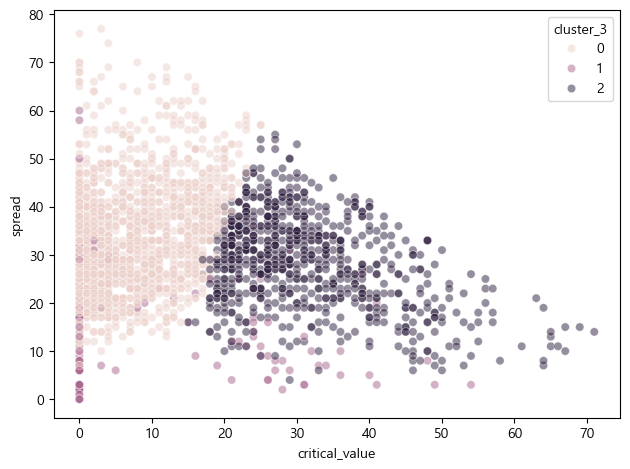

In [17]:
## 6. 비지도 군집으로 그룹 확인
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df[['critical_value','spread','peak_ratio']].values
X_std = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=0).fit(X_std)
df['cluster_3'] = kmeans.labels_

sns.scatterplot(
    data=df.sample(3000, random_state=0),
    x='critical_value', y='spread',
    hue='cluster_3', alpha=0.5
)
plt.tight_layout()
plt.show()
